In [1]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,roc_auc_score,recall_score,f1_score,confusion_matrix,precision_score,classification_report,roc_curve
from mlxtend.plotting import plot_decision_regions

In [2]:
# Importing Dataset
df = pd.read_csv('https://raw.githubusercontent.com/MohammedAyanSyed/projects/refs/heads/main/sklearn-ml-projects/Classfication_Projects/AI_misuse/Ai_system_misuse.csv')

In [3]:
# Dataset Info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   user_id               200000 non-null  object 
 1   user_type             200000 non-null  object 
 2   country               200000 non-null  object 
 3   request_type          200000 non-null  object 
 4   model_used            200000 non-null  object 
 5   device_type           200000 non-null  object 
 6   prompt_length         200000 non-null  int64  
 7   requests_per_min      200000 non-null  float64
 8   toxic_score           200000 non-null  float64
 9   jailbreak_score       200000 non-null  float64
 10  anomaly_score         200000 non-null  float64
 11  failed_requests       200000 non-null  int64  
 12  session_duration_sec  200000 non-null  int64  
 13  api_cost_usd          200000 non-null  float64
 14  misuse_label          200000 non-null  int64  
dtype

,prompt_length,requests_per_min,toxic_score,jailbreak_score,anomaly_score,failed_requests,session_duration_sec,api_cost_usd,misuse_label
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,2250.951925,70.266785,0.500239,0.499318,0.498468,14.502900,4512.939655,3.500381,0.833085
std,1296.427164,40.381297,0.289212,0.288584,0.288743,8.645838,2592.214175,2.019292,0.372901
min,5.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000,0.001000,0.000000
25%,1129.000000,35.340000,0.249000,0.249000,0.248000,7.000000,2273.000000,1.754000,1.000000
50%,2250.000000,70.410000,0.500000,0.500000,0.498000,15.000000,4515.000000,3.502000,1.000000
75%,3370.000000,105.260000,0.751000,0.749000,0.747000,22.000000,6754.250000,5.248000,1.000000
max,4499.000000,140.000000,1.000000,1.000000,1.000000,29.000000,8999.000000,7.000000,1.000000


In [4]:
# Null Check
df.isnull().sum()

,0
user_id,0
user_type,0
country,0
request_type,0
model_used,0
device_type,0
prompt_length,0
requests_per_min,0
toxic_score,0
jailbreak_score,0


# EDA (Visualization)

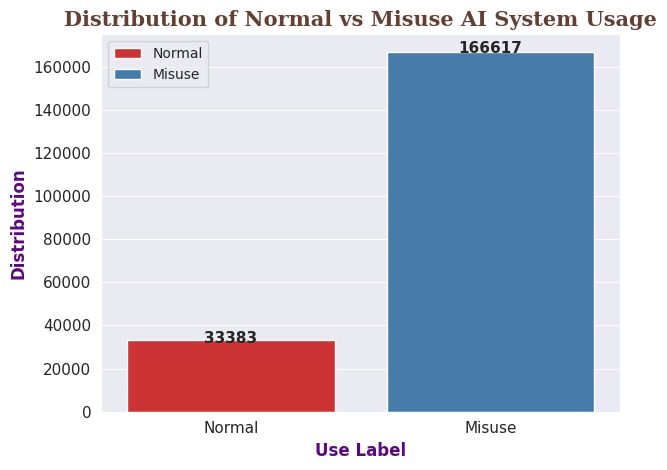

In [5]:
# Page Theme
sns.set_style('darkgrid')
# Countplot
ax = sns.countplot(x='misuse_label',data=df,hue='misuse_label',palette='Set1')

# Annotation
for i in ax.patches:
    height = i.get_height()
    if height>0:
        plt.text(i.get_x()+i.get_width()/2,height+height*0.01,round(height),ha='center',va='center',fontweight='bold',
                fontsize=11,fontfamily='Times New Roman')

# Styling Title and Labels
plt.title('Distribution of Normal vs Misuse AI System Usage',fontweight='bold',fontsize=15,fontfamily='Serif',color='#634033')
plt.xlabel('Use Label',fontweight='bold',fontsize=12,color='#5C097D')
plt.ylabel('Distribution',fontweight='bold',fontsize=12,color='#5C097D')
plt.xticks(ticks=[0,1],labels=['Normal','Misuse'])
plt.tick_params(axis='both',labelsize=11)
plt.legend(['Normal','Misuse'])
# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# This plot shows distribution of normal vs misuse AI system usage.
# The dataset is imbalanced, misuse cases forming a larger portion of data.
# Due to imbalance, I will experiment with techniques like class weights or resampling.
# However I will still validate metrics like precision , recall and ROC-AUC curve to ensure balanced performance.

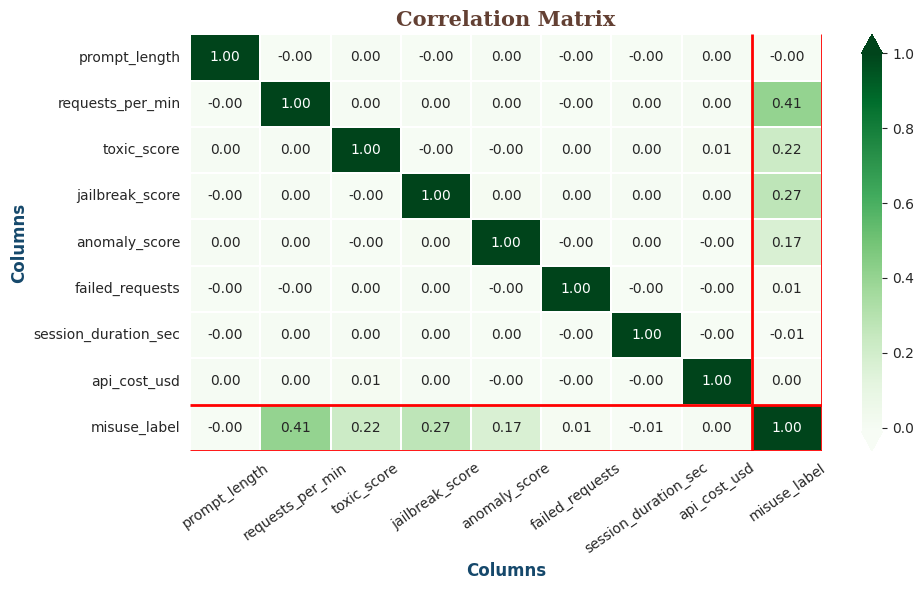

In [6]:
# Plot Size
plt.figure(figsize=(10,6))

# Heatmap
cols = df.select_dtypes(exclude='object').columns.to_list()
relation = df[cols].corr()
target_idx = cols.index('misuse_label')
c = {'shrink':1,'extend':'both'}
sns.heatmap(relation,annot=True,fmt='.2f',linewidths=0.1,cmap='Greens',cbar_kws=c)

# Annotation
plt.hlines(y=target_idx,xmin=0,xmax=len(cols),color='r',linewidths=2)
plt.hlines(y=target_idx+1,xmin=0,xmax=len(cols),color='r',linewidths=2)
plt.vlines(x=target_idx,ymin=0,ymax=len(cols),color='r',linewidths=2)
plt.vlines(x=target_idx+1,ymin=0,ymax=len(cols),color='r',linewidths=2)

# Styling Title and Labels
plt.title('Correlation Matrix',fontweight='bold',fontsize=15,fontfamily='Serif',color='#634033')
plt.xlabel('Columns',fontweight='bold',fontsize=12,color='#15486B')
plt.ylabel('Columns',fontweight='bold',fontsize=12,color='#15486B')
plt.xticks(rotation=35)

# Page Layout
plt.tight_layout()
plt.show()

# Insights:
# This correlation matrix shows relationships among numerical features in tdataset.
# Most features low to moderate correlation, least indicating Collinearity.
# Based on this analysis, these features are expected to be important for classification.

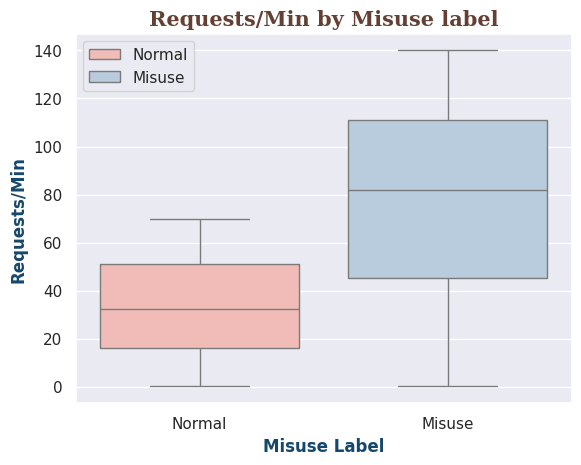

In [7]:
# Page Theme
sns.set_theme(style='darkgrid')

# Boxplot
sns.boxplot(x='misuse_label',y='requests_per_min',data=df,hue='misuse_label',palette='Pastel1')

# Styling Title and Labels
plt.title('Requests/Min by Misuse label',fontweight='bold',fontsize=15,fontfamily='Serif',color='#634033')
plt.xlabel('Misuse Label',fontweight='bold',fontsize=12,color='#15486B')
plt.ylabel('Requests/Min',fontweight='bold',fontsize=12,color='#15486B')
plt.xticks(ticks=[0,1],labels=['Normal','Misuse'])
plt.legend(['Normal','Misuse'])

# Page Layout
plt.tight_layout
plt.show()

# Insights:
# This boxplot compares the request rate between normal and misuse users.
# Misuse cases show a significantly higher median and wider spread of requests per minute
# Requests per minute is a strong candidate feature for misuse classification

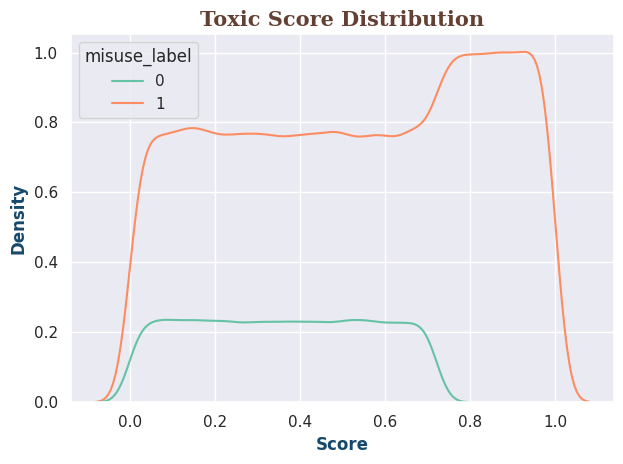

In [8]:
# Page Theme
sns.set_theme(style='darkgrid')
# KDE
sns.kdeplot(x='toxic_score',data=df,hue='misuse_label',palette='Set2')

# Styling Title and Labels
plt.title('Toxic Score Distribution',fontweight='bold',fontsize=15,fontfamily='Serif',color='#634033')
plt.xlabel('Score',fontweight='bold',fontsize=12,color='#15486B')
plt.ylabel('Density',fontweight='bold',fontsize=12,color='#15486B')

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# This KDE plot illustrates the distribution of toxic_score for normal and misuse AI system usage.
# Misuse cases show higher density at toxicity scores, indicating harmful or behavior.
# Normal usage is concentrated at lower toxicity values.

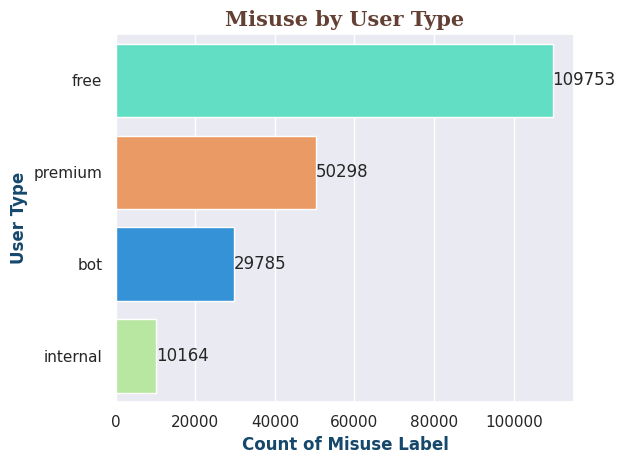

In [9]:
# Page Theme
sns.set_theme(style='darkgrid')
# Barplot
misuse_user = df.groupby('user_type')['misuse_label'].count().reset_index()
order = misuse_user.sort_values(by='misuse_label',ascending=False)['user_type']
ax = sns.barplot(y='user_type',x='misuse_label',data=misuse_user,errorbar=None,hue='user_type',palette='rainbow',orient='horizontal',
                order=order)

# Annotation
for i in ax.patches:
    wide = i.get_width()
    if wide>0:
        plt.text(wide+0.1,i.get_y()+i.get_height()/2,int(wide),ha='left',va='center')
plt.title('Misuse by User Type',fontweight='bold',fontsize=15,fontfamily='Serif',color='#634033')
plt.xlabel('Count of Misuse Label',fontweight='bold',fontsize=12,color='#15486B')
plt.ylabel('User Type',fontweight='bold',fontsize=12,color='#15486B')

# Page Layout
plt.tight_layout()
plt.show()

# Insights :
# This bar plot shows distribution of misuse cases across different user types.
# Certain user categories contribute higher misuse events.
# This suggests that misuse behavior is strongly influenced by user type.

# Feature Engineering

In [10]:
Overall_risk = (df['anomaly_score']+df['toxic_score']+df['jailbreak_score'])/3
df.insert(11,'Overall_risk',Overall_risk)
df['Session in Minutes'] = df['session_duration_sec']/60
correct = df['requests_per_min']*60-df['failed_requests']
total = df['requests_per_min']*60
Successful_requests_rate = correct/total*100
df.insert(14,'Successful_requests_rate',Successful_requests_rate)
Failed_requests_rate = df['failed_requests']/total*100
df.insert(13,'Failed_requests_rate',Failed_requests_rate)
Session_Load = df['requests_per_min']+df['Session in Minutes']
df.insert(16,'Session_Load',Session_Load)

# I engineered composite risk, session-level temporal features, and efficiency metrics to capture abnormal AI system usage behavior.

 # Model Building

In [11]:
# Train-Test Split
independent = df.drop('misuse_label',axis=1)
dependent = df['misuse_label']
Xtrain,Xtest,ytrain,ytest = train_test_split(independent,dependent,train_size=0.8,random_state=37)

# Column Transform and Pipeline
o_cols = Xtrain.select_dtypes('object').columns.to_list()
n_cols = Xtrain.select_dtypes(exclude='object').columns.to_list()
prep = ColumnTransformer([('Encode',OneHotEncoder(handle_unknown='ignore'),o_cols),('Scaling',StandardScaler(),n_cols)])
pipe = Pipeline([('prep',prep),('smote',SMOTE(k_neighbors=2,sampling_strategy='minority')),('model',LGBMClassifier())])

# Model FIt and CV
paras  = {
    'model__learning_rate': [0.1,0.01,0.05],
    'model__max_depth':[x for x in range(4,9)],
    'model__num_leaves':[x for x in range(4,11)],
    'model__bagging_fraction':[0.5,0.6],
    'model__feature_fraction':[0.5,0.6],
    'model__n_estimators':[110,120,130,100]
}

mod = RandomizedSearchCV(pipe,paras,cv=3,verbose=2,n_jobs=-1,n_iter=3,error_score='raise',random_state=52)
mod.fit(Xtrain,ytrain)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
[LightGBM] [Info] Number of positive: 133348, number of negative: 133348
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 6.099365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32226
[LightGBM] [Info] Number of data points in the train set: 266696, number of used features: 3635
[LightGBM] [Info] [binary:Boo

RandomizedSearchCV(cv=3, error_score='raise',
                   estimator=Pipeline(steps=[('prep',
                                              ColumnTransformer(transformers=[('Encode',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['user_id',
                                                                                'user_type',
                                                                                'country',
                                                                                'request_type',
                                                                                'model_used',
                                                                                'device_type']),
                                                                              ('Scaling',
                                                                               StandardScaler(),
                                                                               ['prompt_length',
                                                                                'requests_per_min',
                                                                                'toxic_score',
                                                                                'jailbreak_score',
                                                                                'anomaly_score',
                                                                                'O...
                                              SMOTE(k_neighbors=2,
                                                    sampling_strategy='minority')),
                                             ('model', LGBMClassifier())]),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'model__bagging_fraction': [0.5, 0.6],
                                        'model__feature_fraction': [0.5, 0.6],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.05],
                                        'model__max_depth': [4, 5, 6, 7, 8],
                                        'model__n_estimators': [110, 120, 130,
                                                                100],
                                        'model__num_leaves': [4, 5, 6, 7, 8, 9,
                                                              10]},
                   random_state=52, verbose=2)

In [13]:
# Model Best Params
best_params = mod.best_params_
best_params

{'model__num_leaves': 6,
 'model__n_estimators': 100,
 'model__max_depth': 6,
 'model__learning_rate': 0.05,
 'model__feature_fraction': 0.6,
 'model__bagging_fraction': 0.5}

# Evaluation

In [14]:
pred = mod.predict(Xtest)

# ----------Accuracy Score----------
acc_score = accuracy_score(ytest,pred)
print('Accuracy Score : ',acc_score)
# Overall model correctly classifies most samples, but accuracy alone is not sufficient due to class imbalance

# ----------Precision Score----------
pre_score = precision_score(ytest,pred)
print('Precision Score : ',pre_score)
# High precision indicates that when model predicts the positive class,
# almost always correct, resulting in very low false positives.

# ----------Recall Score----------
re_score = recall_score(ytest,pred)
print('Recall Score : ',re_score)
# High recall shows model correctly identifies almost all actual positive cases,
# indicating very few false negatives, which is crucial for imbalanced datasets.

# ----------f1 score----------
f1 = f1_score(ytest,pred)
print('f1 score : ',f1)
# High F1-score shows a strong balance between precision and recall,
# indicating a stable and reliable model

# ----------Classification Report----------
report = classification_report(ytest,pred)
print(report)
# The classification report provides class-wise precision, recall, and F1-score,
# showing balanced performance across both classes

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
Accuracy Score :  0.995175
Precision Score :  0.9997280473801897
Recall Score :  0.9944693257987917
f1 score :  0.9970917529346172
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      6731
           1       1.00      0.99      1.00     33269

    accuracy                           1.00     40000
   macro avg       0.99      1.00      0.99     40000
weighted avg       1.00      1.00      1.00     40000



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


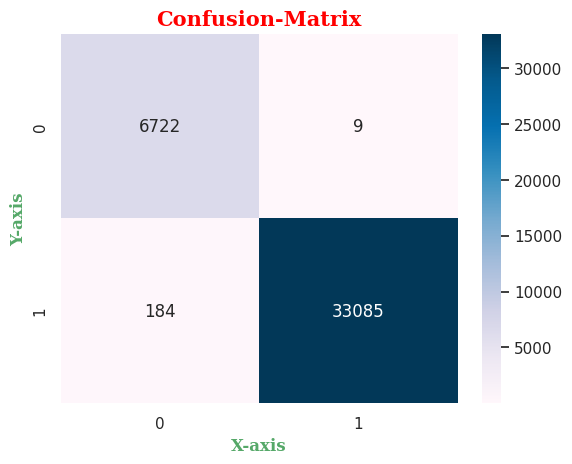

In [15]:
# ----------Confusion Matrix----------
matrix = confusion_matrix(ytest,pred)
sns.heatmap(matrix,annot=True,fmt='.0f',cmap='PuBu')
plt.title('Confusion-Matrix',fontweight='bold',fontfamily='Serif',fontsize=15,color='red')
plt.xlabel('X-axis',fontweight='bold',fontfamily='Serif',fontsize=12,color='g')
plt.ylabel('Y-axis',fontweight='bold',fontfamily='Serif',fontsize=12,color='g')
plt.show()

# Insights
# True Negative - 6722
# False Positive - 9
# False Negative - 184
# True Positive - 33085

In [28]:
# Threshold Tuning
thresholds = 0.25
values = mod.predict_proba(Xtest)[:,1]
pred_custom = (values >= thresholds).astype(int)
print("Precision Score:", precision_score(ytest, pred_custom))
print("Recall Score:", recall_score(ytest, pred_custom))
print("F1 Score:", f1_score(ytest, pred_custom))
print(confusion_matrix(ytest, pred_custom))

# Custom threshold tuning improved recall and reduced false negatives,
# making the system more reliable for AI misuse detection where minimizing undetected misuse is Dangerous

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.5, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5
Precision Score: 0.9978960024045687
Recall Score: 0.9979259971745469
F1 Score: 0.9979109995641654
[[ 6661    70]
 [   69 33200]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


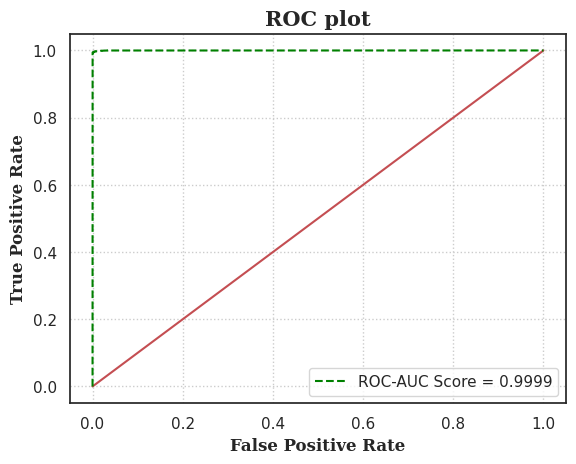

In [29]:
# ROC-AUC curve

fpr,tpr,thresholds = roc_curve(ytest,values)
roc_auc = roc_auc_score(ytest,values)
plt.plot([0,1],[0,1],color='r')
plt.plot(fpr,tpr,color='green',linestyle='--',label=f'ROC-AUC Score = {roc_auc:.4f}')
plt.title('ROC plot',fontweight='bold',fontfamily='Serif',fontsize=15)
plt.xlabel('False Positive Rate',fontweight='bold',fontfamily='Serif',fontsize=12)
plt.ylabel('True Positive Rate',fontweight='bold',fontfamily='Serif',fontsize=12)
plt.legend()
plt.grid(linestyle=':')
plt.show()

# Insights:
# ROC–AUC curve demonstrates near-perfect class separability.

In [30]:
# Saving Model
import joblib
joblib.dump(mod,'AI_Misuse_Detection')

['AI_Misuse_Detection']